In [ ]:
from nrem_analysis.constant import PROCESSED_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def unwrap_epochs(data: nap.Tsd):
    d = data.d.copy()
    t = data.t

    for start, end in zip(
        data.time_support.start,
        data.time_support.end,
    ):
        i = np.searchsorted(t, start, side="left")
        j = np.searchsorted(t, end, side="right")
        d[i:j] = np.unwrap(d[i:j])

    return nap.Tsd(t=t, d=d, time_support=data.time_support,)

def detect_upstates(
    spikes: nap.TsGroup,
    bin_size = 0.01,
    percentile = 80,
    merge_thr = 0.1,
    short_thr = 0.04,
    long_thr = 2,
    time_units='s'
    ) -> nap.IntervalSet:
    x = spikes.count(bin_size=bin_size, time_units=time_units).sum(axis=1)
    x = x / bin_size
    x = x.smooth(std=2 * bin_size, time_units=time_units)
    thr = np.percentile(x, q=percentile)

    up_states = x.threshold(thr, method='above').time_support
    up_states = up_states.merge_close_intervals(threshold=merge_thr, time_units=time_units)
    up_states = up_states.drop_short_intervals(threshold=short_thr, time_units=time_units)
    up_states = up_states.drop_long_intervals(threshold=long_thr, time_units=time_units)
    return up_states, thr

def compute_unwrapped_sta(
    data: nap.Tsd,
    units: nap.TsGroup,
    *,
    window,
    time_unit,
    ):
    stas = []
    errors = []

    for uid in units.index:
        events = units[uid].restrict(data.time_support)
        
        if len(events) == 0:
            print(f"No events in {uid}. Filling with NaN")
            stas.append(None)
            errors.append(None)
            continue

        perievent = nap.compute_perievent(
            data = data,
            events = events,
            window = window,
            time_unit = time_unit
        )
        
        # drop event columns with NaN
        nan_mask = np.any(np.isnan(perievent.d), axis=0)
        perievent = perievent[:, ~nan_mask]
        
        # subtract baseline
        zero_idx = np.argmin(np.abs(perievent.index))
        perievent = perievent - perievent[zero_idx]

        errors.append(stats.sem(perievent, axis=1))
        sta = np.mean(perievent, axis=1)

        stas.append(sta)
        times = sta.t

    stas = [
        np.full(times.shape, np.nan) if sta is None else sta
        for sta in stas
    ]

    errors = [
        np.full(times.shape, np.nan) if error is None else error
        for error in errors
    ]
    
    return np.column_stack(stas), np.column_stack(errors)

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]
NREM_STA_KWARGS = dict(
    window=(-51, 51),
    time_unit="ms",
)

In [ ]:
stas, errors, tsi = [], [], []

for mouse_id in MOUSE_IDS:
    data_dir = PROCESSED_DIR / "dual" / mouse_id

    turn_units  = nap.load_file(data_dir / "turn_units.npz")
    hd_units    = nap.load_file(data_dir / "hd_units.npz")
    virtual_hd  = nap.load_file(data_dir / "virtual_hd.npz") 
    sleep       = nap.load_file(data_dir / "sleep.npz")
    session     = nap.load_file(data_dir / "session.npz")

    nrem = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])

    up_states, _ = detect_upstates(hd_units.restrict(nrem))
    up_hd = virtual_hd.restrict(up_states)
    up_hd = unwrap_epochs(np.deg2rad(up_hd))
    
    sta, error = compute_unwrapped_sta(up_hd, turn_units, **NREM_STA_KWARGS)
    
    stas.append(stas)
    errors.append(error)
    tsi.append(turn_units['turn_index'].values)

stas = np.column_stack(stas)
errors = np.column_stack(errors)
tsi = np.concatenate(tsi)

No events in 207. Filling with NaN


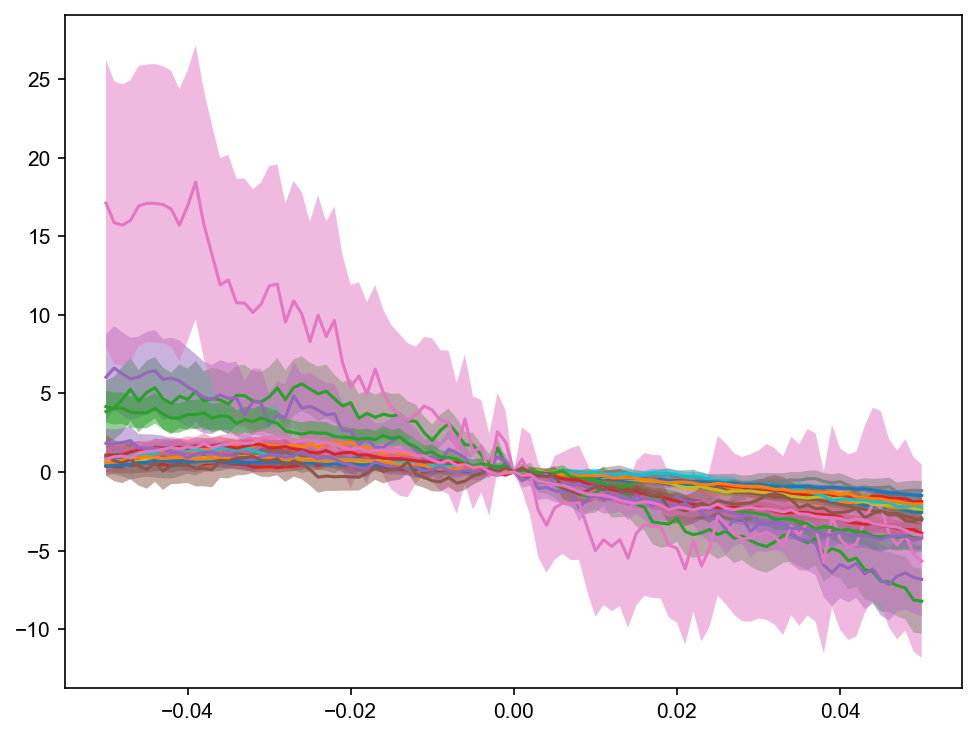

In [287]:
t = stas.index
for idx in range(stas.shape[1]):
    plt.fill_between(t, stas[:, idx] - errors[:, idx], stas[:, idx] + errors[:, idx], alpha=0.5)
    plt.plot(t, stas.d[:, idx])

In [273]:
order = np.argsort(turn_units['turn_index'])
zero_idx = np.argmin(np.abs(turn_units['turn_index'].values[order])).item() + 1

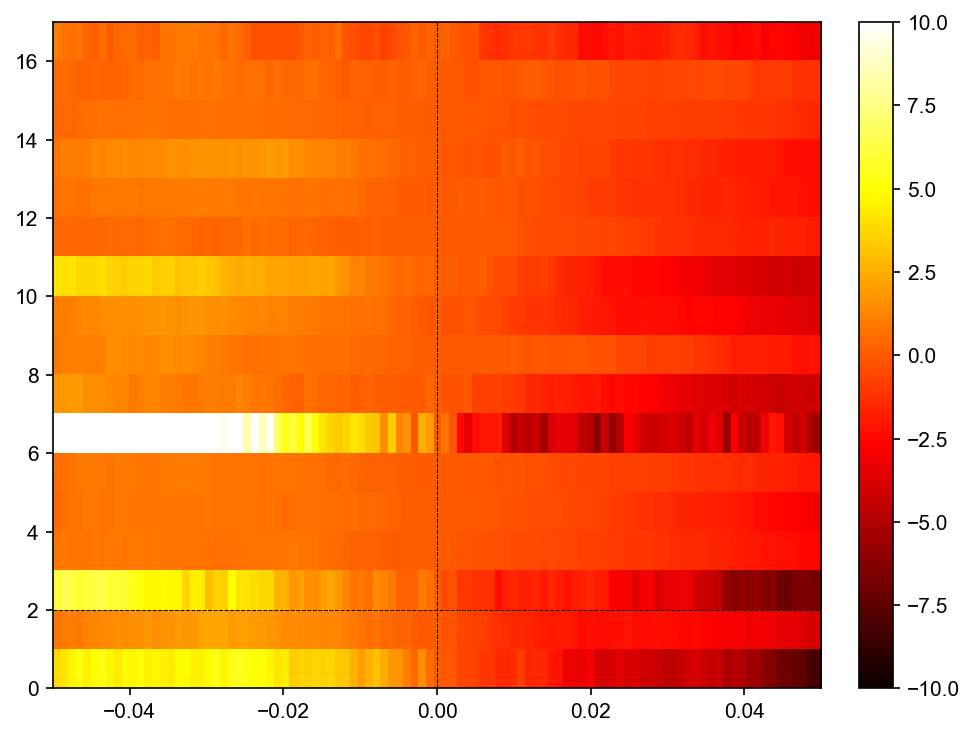

In [276]:
from matplotlib.colors import TwoSlopeNorm
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

im = plt.imshow(
    stas.d.T[order, :],
    cmap='hot',
    aspect='auto',
    origin='lower',
    extent=[stas.t[0], stas.t[-1], 0, stas.shape[1]],     
    norm=norm,
    )

plt.axhline(zero_idx, color='k', linestyle='--', linewidth=0.5)
plt.colorbar(im)
plt.axvline(0, color='k', linestyle='--', linewidth=0.5)